In [2]:
import json
import pandas as pd
import numpy as np
import seaborn as sns

from evolve.ranked_mlp import MLPRegressorWithRankedLoss 
from sklearn.neural_network import MLPRegressor

#%load_ext autoreload
#%autoreload 2

from app.helpers.sequence_util import (
    get_measured_and_unmeasured_mutant_seq_ids,
    get_loci_set,
    process_and_validate_evolve_input_files,
)


In [3]:
from evolve.evolvetest import clean_embeddings_df
wt_aa_seq = 'MRHGDISSSNDTVGVAVVNYKMPRLHTAAEVLDNARKIAEMIVGMKQGLPGMDLVVFPEYSLQGIMYDPAEMMETAVAIPGEETEIFSRACRKANVWGVFSLTGERHEEHPRKAPYNTLVLIDNNGEIVQKYRKIIPWCPIEGWYPGGQTYVSEGPKGMKISLIICDDGNYPEIWRDCAMKGAELIVRCQGYMYPAKDQQVMMAKAMAWANNCYVAVANAAGFDGVYSYFGHSAIIGFDGRTLGECGEEEMGIQYAQLSLSQIRDARANDQSQNHLFKILHRGYSGLQASGDGDRGLAECPFEFYRTWVTDAEKARENVERLTRSTTGVAQCPVGRLPYEGLEKEA'
raw_embedding_df = pd.read_csv(r'C:\Users\ese\EsmcBench\backend\EvolveTest\amiE\embeddings\amiE_esmc_300m_WT.csv')
raw_activity_df = pd.read_excel(r'C:\Users\ese\EsmcBench\backend\EvolveTest\DMS_data\amiE_Acet_dms.xlsx')
cleaned_embeddings_df = clean_embeddings_df(raw_embedding_df,raw_activity_df)


In [4]:
# raw_activity_df = raw_activity_df.groupby('seq_id').agg({'activity': 'mean', 'seq_id': 'first'})

In [5]:
activity_df, embedding_df = process_and_validate_evolve_input_files(wt_aa_seq, cleaned_embeddings_df, cleaned_embeddings_df)

In [6]:
measured_mutants, unmeasured_mutants = get_measured_and_unmeasured_mutant_seq_ids(
    activity_df, embedding_df
)

# Convert JSON strings to lists and stack them into a 2D numpy array
X_train = np.vstack(
    [json.loads(x) for x in embedding_df.loc[activity_df.index].embedding]
)
y_train = activity_df.activity.to_numpy()
 

In [13]:
model = MLPRegressor(random_state=1, 
                     hidden_layer_sizes=(500,100,50,),
                     #early_stopping=True,
                     #tol=1e-4,
                     #learning_rate_init=.001,
                     max_iter=5000,verbose=True,
                     #learning_rate='constant',
                     #n_iter_no_change=500,
                     #activation='tanh',
                     )
model.fit(X_train, y_train)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Get predictions on the training set
y_pred = model.predict(X_train)
# 2. Compute and print basic metrics
r2 = r2_score(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)

print("Training Spearman:", spearmanr(y_train, y_pred).correlation)
print("Training MSE:", mse)
print("Training RMSE:", rmse)
print("Training MAE:", mae)

Iteration 1, loss = 0.73250871
Iteration 2, loss = 0.73268427
Iteration 3, loss = 0.73247675
Iteration 4, loss = 0.73175278
Iteration 5, loss = 0.73170884
Iteration 6, loss = 0.73200747
Iteration 7, loss = 0.73131880
Iteration 8, loss = 0.73119651
Iteration 9, loss = 0.73113017
Iteration 10, loss = 0.73261357
Iteration 11, loss = 0.73008972
Iteration 12, loss = 0.73095900
Iteration 13, loss = 0.72770476
Iteration 14, loss = 0.72674017
Iteration 15, loss = 0.72544551
Iteration 16, loss = 0.71790896
Iteration 17, loss = 0.71352500
Iteration 18, loss = 0.71722990
Iteration 19, loss = 0.70584563
Iteration 20, loss = 0.70082260
Iteration 21, loss = 0.70561815
Iteration 22, loss = 0.69392480
Iteration 23, loss = 0.69440066
Iteration 24, loss = 0.69168378
Iteration 25, loss = 0.68617404
Iteration 26, loss = 0.68852808
Iteration 27, loss = 0.69224418
Iteration 28, loss = 0.68954492
Iteration 29, loss = 0.68886769
Iteration 30, loss = 0.69321816
Iteration 31, loss = 0.69016912
Iteration 32, los

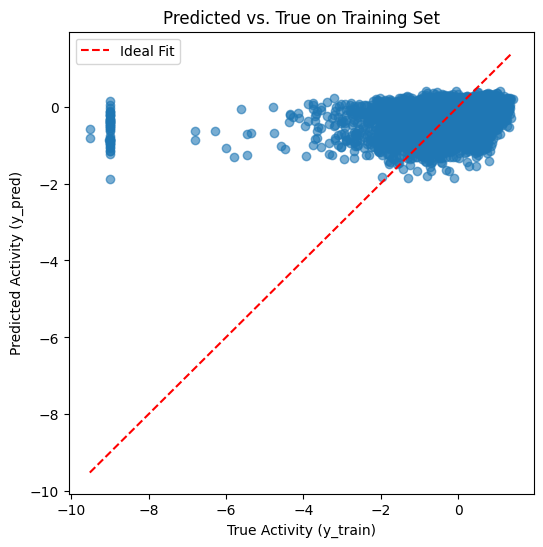

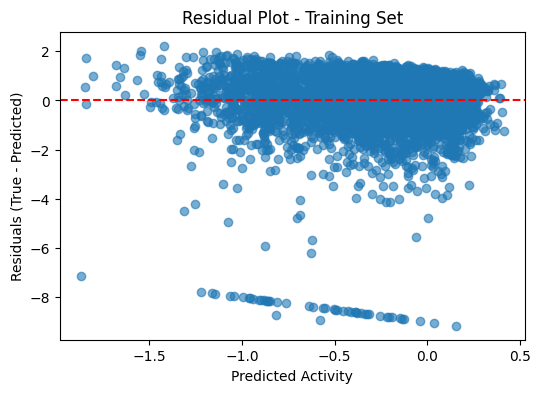

In [14]:
# 3. Plot true vs. predicted values
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred, alpha=0.6)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--', label='Ideal Fit')
plt.xlabel('True Activity (y_train)')
plt.ylabel('Predicted Activity (y_pred)')
plt.title('Predicted vs. True on Training Set')
plt.legend()
plt.show()

# 4. (Optional) Plot the residuals
residuals = y_train - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Activity')
plt.ylabel('Residuals (True - Predicted)')
plt.title('Residual Plot - Training Set')
plt.show()

# Cool. Now cross-validate.

In [15]:
from app.helpers.sequence_util import get_cross_validation_holdout_sets, get_cv_splits
print(len(measured_mutants))
#display(measured_mutants).head(3)
cv_holdout_sets, cv_viable_loci = get_cross_validation_holdout_sets(
  measured_mutants,
  min_held_out_mutants=5,
  max_held_out_mutants=12,
)
len(cv_holdout_sets), len(cv_viable_loci)

6289


(1, 1)

In [16]:
cv_splits = get_cv_splits(activity_df.index, cv_holdout_sets, n_splits=10)
for train_indices, test_indices in cv_splits:
    print(f'{100.0 * len(test_indices) / (len(train_indices) + len(test_indices)):.1f}% in holdout')

0.2% in holdout


In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr

# Custom scorer using Spearman correlation
def spearman_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

spearman_score = make_scorer(spearman_scorer, greater_is_better=True)

# scores = cross_val_score(model, X_train, y_train, cv=cv_splits, scoring='r2', n_jobs=-1)
scores = cross_val_score(model, X_train, y_train, cv=cv_splits, scoring=spearman_score, n_jobs=-1)

In [18]:
pd.Series(scores).describe()

count    1.000000
mean     0.482517
std           NaN
min      0.482517
25%      0.482517
50%      0.482517
75%      0.482517
max      0.482517
dtype: float64

In [19]:
print("Cross-Val spearman scores:", scores)
print("Mean spearman:", np.mean(scores))
print("Std spearman:", np.std(scores))

Cross-Val spearman scores: [0.48251748]
Mean spearman: 0.4825174825174825
Std spearman: 0.0


Text(0.5, 1.0, 'Distribution of CV Spearman Scores')

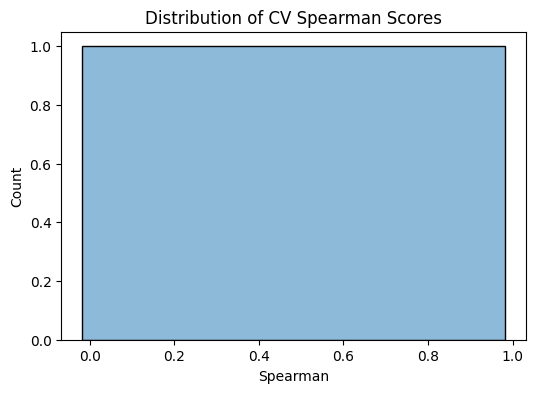

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(scores, kde=True)
plt.xlabel("Spearman")
plt.ylabel("Count")
plt.title("Distribution of CV Spearman Scores")

Iteration 1, loss = 0.73455304
Iteration 2, loss = 0.73291766
Iteration 3, loss = 0.73273674
Iteration 4, loss = 0.73379174
Iteration 5, loss = 0.73231193
Iteration 6, loss = 0.73231452
Iteration 7, loss = 0.73198733
Iteration 8, loss = 0.73093948
Iteration 9, loss = 0.73058833
Iteration 10, loss = 0.73416744
Iteration 11, loss = 0.73083214
Iteration 12, loss = 0.73114256
Iteration 13, loss = 0.72809731
Iteration 14, loss = 0.72464037
Iteration 15, loss = 0.72000662
Iteration 16, loss = 0.71662613
Iteration 17, loss = 0.72272604
Iteration 18, loss = 0.70868645
Iteration 19, loss = 0.70800535
Iteration 20, loss = 0.71299466
Iteration 21, loss = 0.70265788
Iteration 22, loss = 0.69574216
Iteration 23, loss = 0.69395669
Iteration 24, loss = 0.69185746
Iteration 25, loss = 0.69847169
Iteration 26, loss = 0.69200049
Iteration 27, loss = 0.69538261
Iteration 28, loss = 0.69183477
Iteration 29, loss = 0.68525858
Iteration 30, loss = 0.68365660
Iteration 31, loss = 0.68477630
Iteration 32, los

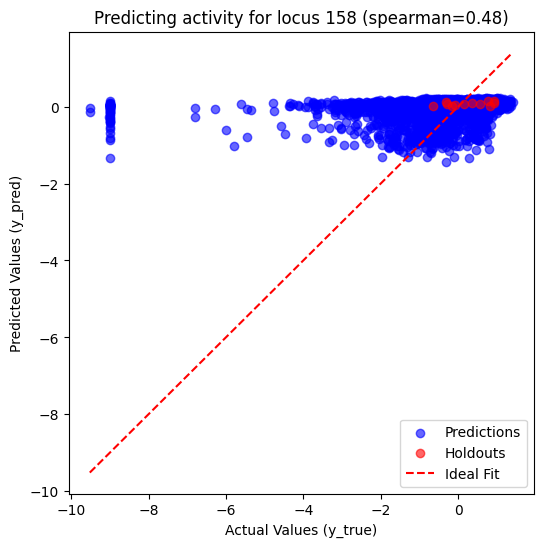

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

def plot_fold_predictions(model, X, y, cv_split, title="Fold Results: Predicted vs. Actual"):
    """
    Plots predicted vs. actual values for a single fold in custom cross-validation.
    
    Parameters:
        model : trained model (e.g., RandomForestRegressor)
            The fitted model to use for predictions.
        X : array-like, shape (n_samples, n_features)
            Feature matrix.
        y : array-like, shape (n_samples,)
            Target values.
        cv_split : tuple of lists
            A tuple (train_indices, test_indices) defining the fold split.
        title : str
            Custom title for the plot.
    
    Returns:
        None
    """
    train_indices, test_indices = cv_split

    # Train the model on the train split
    model.fit(X[train_indices], y[train_indices])
    y_train_pred = model.predict(X[train_indices])
    y_train_true = y[train_indices]

    # Predict on the test split
    y_test_pred = model.predict(X[test_indices])
    y_test_true = y[test_indices]

    # Plot predicted vs. actual
    plt.figure(figsize=(6, 6))
    plt.scatter(y_train_true, y_train_pred, alpha=0.6, label="Predictions", color='blue')
    plt.scatter(y_test_true, y_test_pred, alpha=0.6, label="Holdouts", color='red')
    plt.plot([y.min(), y.max()],
             [y.min(), y.max()],
             'r--', label="Ideal Fit")
    plt.xlabel("Actual Values (y_true)")
    plt.ylabel("Predicted Values (y_pred)")
    # plt.title(f'{title} (R^2={r2_score(y_test_true, y_test_pred):.2f})')
    plt.title(f'{title} (spearman={spearmanr(y_test_true, y_test_pred).correlation:.2f})')
    plt.legend()
    plt.show()

for ii in range(len(cv_splits)):
  plot_fold_predictions(model, X_train, y_train, cv_splits[ii], title=f'Predicting activity for locus {cv_viable_loci[ii]}')

# Spearman actually looks quite good!

Note that R2 did not. But R2 is not a good metric for this problem.

In [22]:
X_unmeasured = np.vstack(
    # [json.loads(x) for x in embedding_df.loc[unmeasured_mutants].embedding]
    [json.loads(x) for x in embedding_df.loc[measured_mutants + unmeasured_mutants].embedding]
)
X_unmeasured.shape

(6289, 960)

In [23]:
y_unmeasured_pred = model.predict(X_unmeasured)


In [24]:
unmeasured_df = pd.DataFrame({
    # 'seq_id': unmeasured_mutants,
    'seq_id': measured_mutants + unmeasured_mutants,
    'predicted_activity': y_unmeasured_pred,
})
unmeasured_df.index = unmeasured_df.seq_id
unmeasured_df['relevant_measured_mutants'] = unmeasured_df.seq_id.apply(
  lambda unmeasured_seq_id: ' '.join([
    m for m in measured_mutants if get_loci_set(m) & get_loci_set(unmeasured_seq_id)
  ])
)
unmeasured_df['actual_activity'] = unmeasured_df.join(
  activity_df.groupby(level=0).activity.mean(), how='left').activity
unmeasured_df = unmeasured_df.sort_values('predicted_activity', ascending=False)
unmeasured_df.to_csv('~/Downloads/predicted_activities_evolvepro.csv')

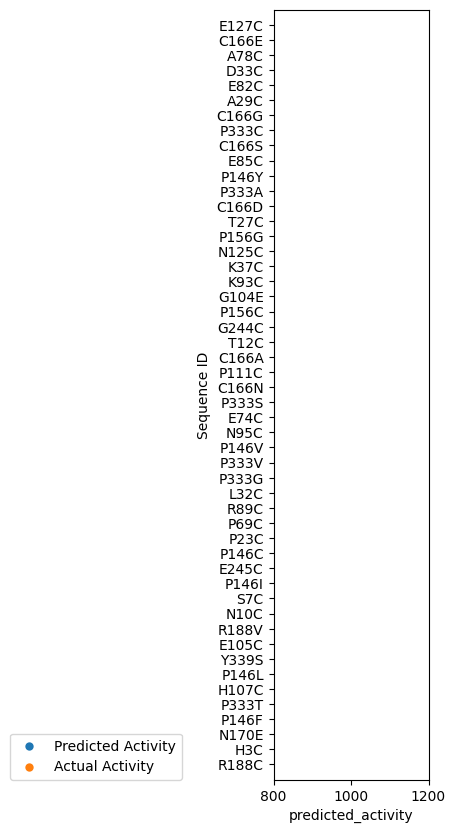

In [25]:
from matplotlib import pyplot as plt
plotting_df = unmeasured_df.iloc[:50].copy()
plotting_df['Sequence ID'] = plotting_df.apply(lambda r: f'{"" if r.relevant_measured_mutants else "*"}{r.seq_id}', axis=1)
plt.figure(figsize=(2,10))
ax = sns.scatterplot(data=plotting_df, 
                     y='Sequence ID', 
                     x='predicted_activity', 
                     linewidth=0,
                     label='Predicted Activity')

ax = sns.scatterplot(data=plotting_df, 
                     y='Sequence ID', 
                     x='actual_activity', 
                     linewidth=0,
                     label='Actual Activity')
ax.set_ylim(50, -1)  # Reverse y-axis to maintain same order
ax.set_xlim(800, 1200)
ax.legend(loc='lower left', 
         bbox_to_anchor=(-1.7, 0),  # Move legend left of plot
         borderaxespad=0)  # Reduce padding
